In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
from skimage.metrics import mean_squared_error, peak_signal_noise_ratio, structural_similarity

This code does the isotropic diffusion of a image and it seems to work. Is it correctly implemented? I want you to make it into a function that receives a image and a number of iteratio as arguments and returns the image with the isotropic diffusion applied.

In [29]:
import numpy as np
from skimage.io import imread
import scipy.ndimage as ndimage

def isotropic_diffusion(image, num_iterations=100, eta=0.1):
    """
    Apply isotropic diffusion (heat equation) to an image.
    
    Parameters:
        image (numpy.ndarray): Grayscale image as a 2D array.
        num_iterations (int): Number of diffusion iterations.
        eta (float): Time step or learning rate.
    
    Returns:
        numpy.ndarray: Diffused image after specified iterations.
    """
    u = image.astype(np.float32)
    u = u / u.max()  # Normalize to [0, 1]

    for _ in range(num_iterations):
        u += eta * ndimage.laplace(u)

    return u


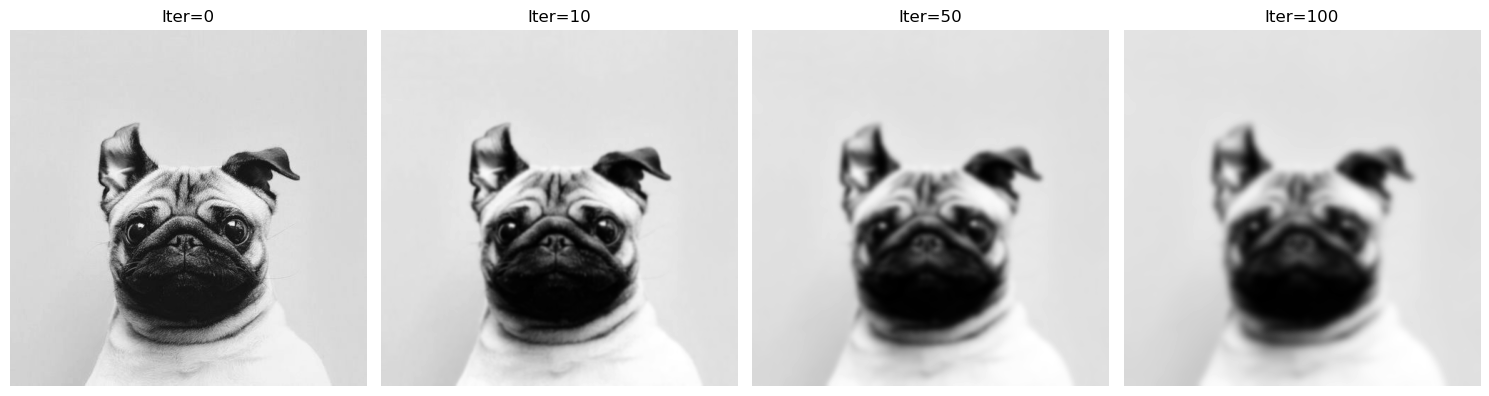

In [30]:
n_iters = [0, 10, 50, 100]

fig, axs = plt.subplots(1, 4, figsize=(15, 15))

for i, n_iter in enumerate(n_iters):
    filtered = isotropic_diffusion(image, n_iter)
    
    ax = axs[i]
    ax.imshow(filtered, cmap='gray')
    ax.set_title(f'Iter={n_iter}')
    ax.axis('off')

plt.tight_layout()
plt.show()

In [26]:
import numpy as np

def anisotropic_diffusion(image, num_iterations=15, eta=0.25, K=15):
    """
    Perona-Malik Anisotropic Diffusion (2D)
    
    Parameters:
        image (np.ndarray): Input grayscale image.
        num_iterations (int): Number of iterations to run.
        eta (float): Time step (should be ≤ 0.25 for stability).
        K (float): Edge threshold parameter (controls edge sensitivity).
    
    Returns:
        np.ndarray: The diffused image.
    """
    u = image.astype(np.float32)
    u = u / u.max()  # Normalize to [0, 1]
    
    for _ in range(num_iterations):
        # Compute gradients in 4 directions
        uN = np.roll(u, -1, axis=0)
        uS = np.roll(u, 1, axis=0)
        uE = np.roll(u, -1, axis=1)
        uW = np.roll(u, 1, axis=1)
        
        # Differences (gradients)
        dN = uN - u
        dS = uS - u
        dE = uE - u
        dW = uW - u
        
        # Diffusion coefficients
        cN = np.exp(-(dN / K)**2)
        cS = np.exp(-(dS / K)**2)
        cE = np.exp(-(dE / K)**2)
        cW = np.exp(-(dW / K)**2)
        
        # Update rule
        u += eta * (cN * dN + cS * dS + cE * dE + cW * dW)
    
    return u


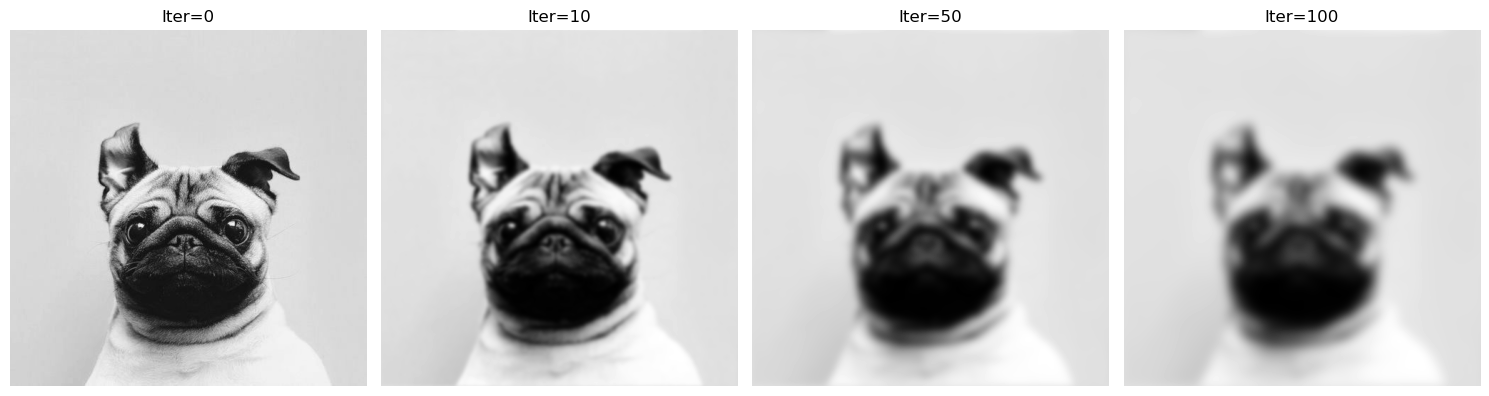

In [28]:
n_iters = [0, 10, 50, 100]

fig, axs = plt.subplots(1, 4, figsize=(15, 15))

for i, n_iter in enumerate(n_iters):
    filtered = anisotropic_diffusion(image, n_iter)
    
    ax = axs[i]
    ax.imshow(filtered, cmap='gray')
    ax.set_title(f'Iter={n_iter}')
    ax.axis('off')

plt.tight_layout()
plt.show()